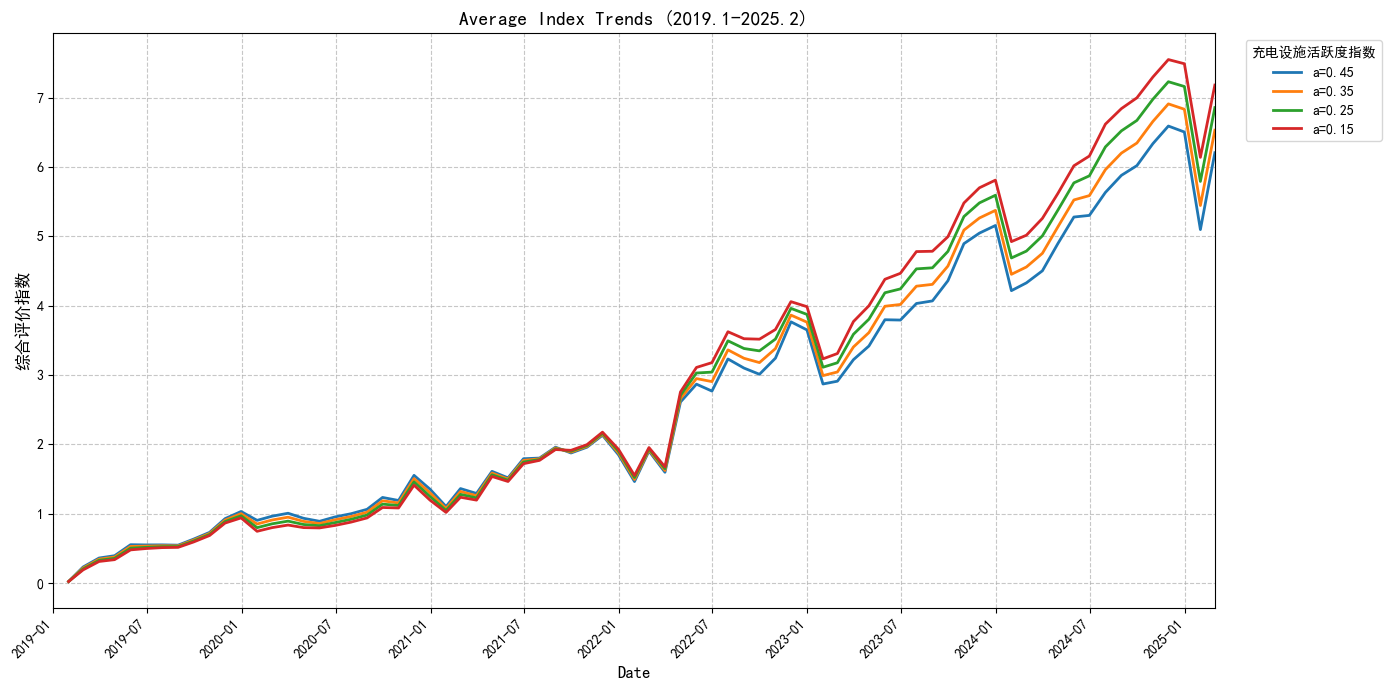

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
df = pd.read_excel('平均指数.xlsx', sheet_name='Sheet1', index_col=0)

# 选择前四列（a=0.45, a=0.35, a=0.25, a=0.15）
columns_to_plot = df.columns[:4]

# 转换索引为日期格式
df.index = pd.to_datetime(df.index)

# 创建画布
plt.figure(figsize=(14, 7))

# 定义颜色和绘制折线
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for col, color in zip(columns_to_plot, colors):
    plt.plot(df.index, df[col], color=color, label=col, linewidth=2)

# 设置横坐标范围
plt.xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2025-03-01'))

# 生成6个月间隔的刻度（格式为年月）
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))  # 1月和7月
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 优化显示效果
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='充电设施活跃度指数', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('Average Index Trends (2019.1-2025.2)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('综合评价指数', fontsize=12)
plt.tight_layout()

# 显示图表
plt.show()

列名： ['燃料电池产量', '新能源汽车销量', '充电设施活跃度指数', '燃料电池综合指数']
综合评价指数已计算并保存到 comprehensive_index.xlsx


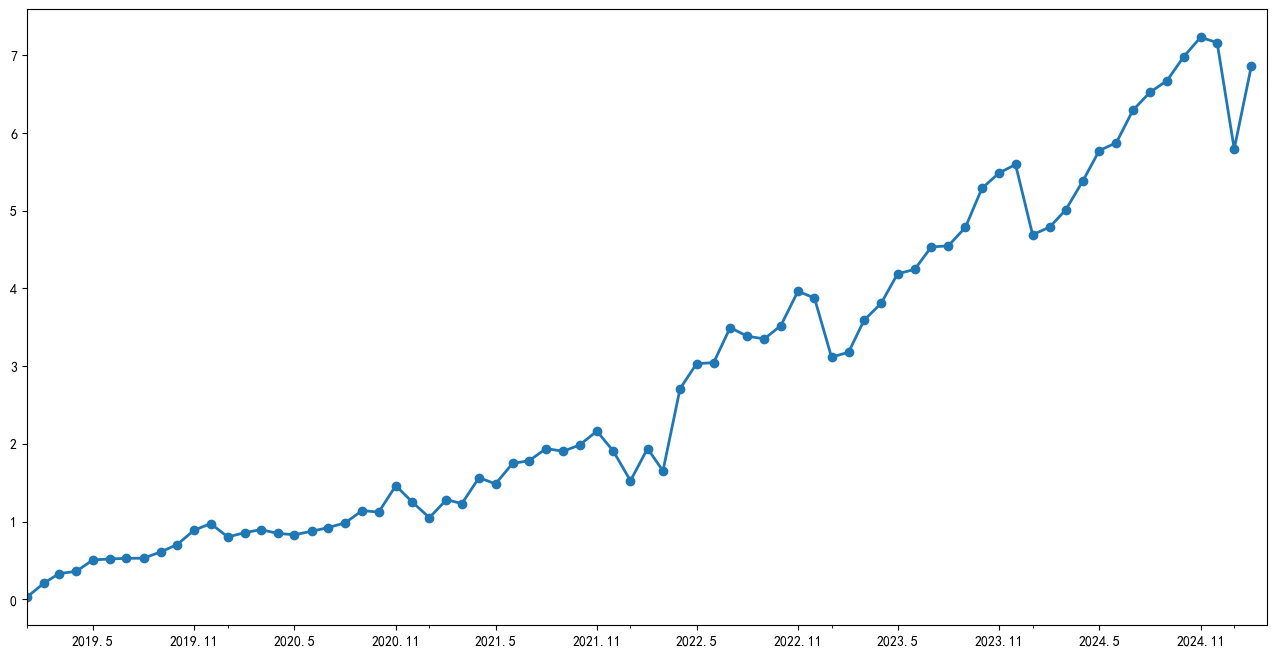

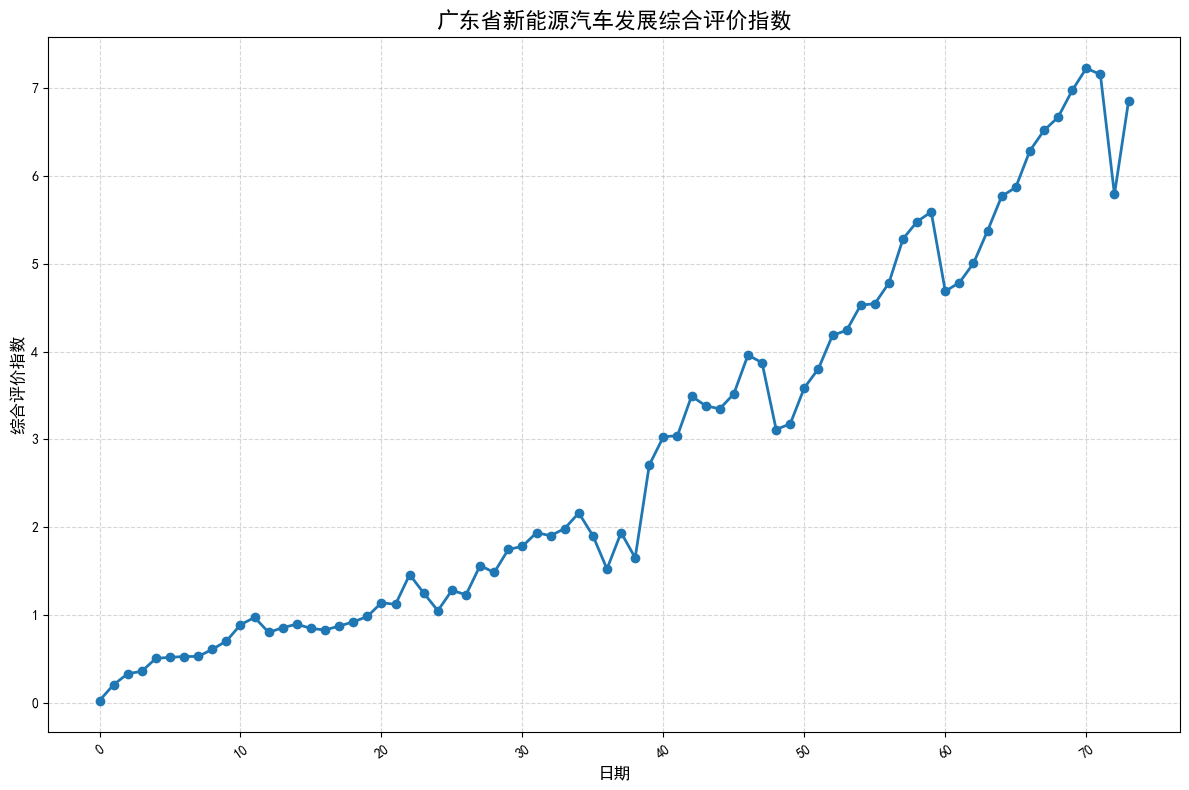

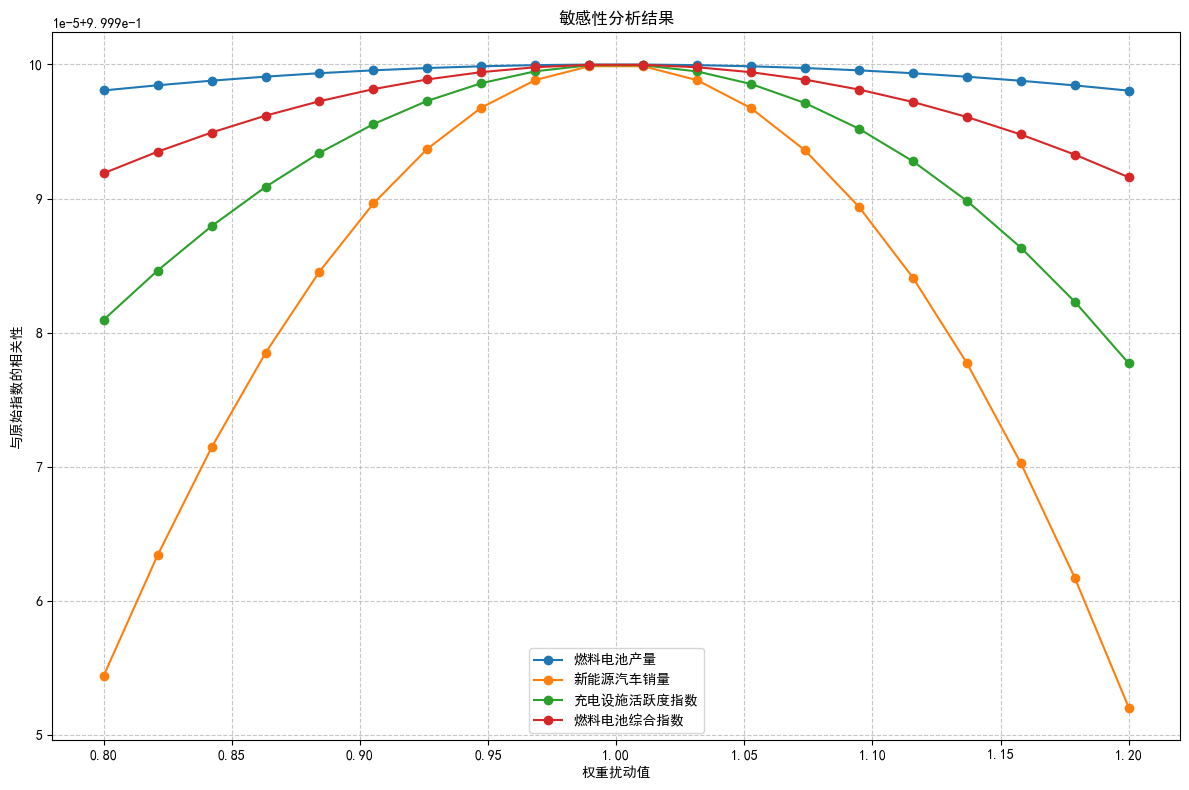

敏感性分析结果已保存到 sensitivity_analysis_results.xlsx


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取Excel文件
file_path = '热力图数据.xlsx'  # 替换为你的文件路径
df = pd.read_excel(file_path)

# 查看列名，确保列名正确
print("列名：", df.columns.tolist())

# 文件中的实际列名
actual_columns = [
    '燃料电池产量',
    '新能源汽车销量',
    '充电设施活跃度指数',
    '燃料电池综合指数'
]

# 代码中定义的列名
defined_columns = [
    '燃料电池产量',
    '新能源汽车销量',
    '充电设施活跃度指数',
    '燃料电池综合指数'
]

# 创建列名映射
column_mapping = dict(zip(actual_columns, defined_columns))

# 重命名列
df.rename(columns=column_mapping, inplace=True)

# 提取需要处理的列
columns = defined_columns

# 确保只对数值列进行操作
numeric_df = df[columns].apply(pd.to_numeric, errors='coerce')

# 数据标准化（Min-Max归一化）
for column in columns:
    if column in numeric_df.columns:
        min_val = numeric_df[column].min()
        max_val = numeric_df[column].max()
        df[column + '_normalized'] = (numeric_df[column] - min_val) / (max_val - min_val)
    else:
        print(f"列 '{column}' 不是数值列。")

# 假设的AHP权重（根据专家判断或经验设定）
ahp_weights = {
    '燃料电池产量': 1,
    '新能源汽车销量': 3,
    '充电设施活跃度指数': 5,
    '燃料电池综合指数': 2
}

# 熵值法计算客观权重
def calculate_entropy_weights(data):
    # 避免除以零或负数
    data = np.where(data <= 0, 1e-10, data)
    # 计算熵值
    entropy = -data * np.log(data)
    entropy = np.nansum(entropy, axis=0)
    # 计算差异系数
    diff_coeff = 1 - entropy / np.log(len(data))
    # 计算客观权重
    weights = diff_coeff / np.sum(diff_coeff)
    return weights

# 提取归一化后的数据
normalized_columns = [col + '_normalized' for col in columns]
normalized_data = df[normalized_columns].values

# 计算熵值法权重
entropy_weights = calculate_entropy_weights(normalized_data)

# 设置权重分配系数α
alpha_values = {
    '燃料电池产量': 0.15,
    '新能源汽车销量': 0.35,
    '充电设施活跃度指数': 0.25,
    '燃料电池综合指数': 0.25
}

# 计算综合权重
combined_weights = []
for i, column in enumerate(columns):
    ahp_weight = ahp_weights[column]
    ent_weight = entropy_weights[i]
    combined_weight = alpha_values[column] * ent_weight + (1 - alpha_values[column]) * ahp_weight
    combined_weights.append(combined_weight)

# 计算广东省新能源汽车发展的综合评价指数
comprehensive_index = np.sum(normalized_data * combined_weights, axis=1)

# 将指数添加到数据框
df['综合评价指数'] = comprehensive_index

# 保存结果到新的Excel文件
output_file_path = 'comprehensive_index.xlsx'
df.to_excel(output_file_path, index=False)

print(f"综合评价指数已计算并保存到 {output_file_path}")


# 生成日期范围（假设数据起始于2019年1月，每月一个数据点）
n_samples = len(df)
start_date = pd.Timestamp('2019-01-01')
dates = pd.date_range(start=start_date, periods=n_samples, freq='MS')  # MS=每月第一天

plt.figure(figsize=(16, 8))
plt.plot(dates, df['综合评价指数'], marker='o', linestyle='-', linewidth=2)

# 设置坐标轴格式
ax = plt.gca()

# 主刻度：每6个月一个刻度
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
# 次刻度：每年一个刻度（可选）
ax.xaxis.set_minor_locator(mdates.YearLocator())  

# 自定义日期格式（显示为"年.月"且月份无前导零）
def format_func(x, pos=None):
    date = mdates.num2date(x)
    return f"{date.year}.{date.month}"

ax.xaxis.set_major_formatter(plt.FuncFormatter(format_func))

# 限制坐标轴范围
ax.set_xlim([pd.Timestamp('2019-01-01'), pd.Timestamp('2025-03-01')])
# 可视化综合评价指数
plt.figure(figsize=(12, 8))
plt.plot(df.index, df['综合评价指数'], marker='o', linestyle='-', linewidth=2)
plt.title('广东省新能源汽车发展综合评价指数', fontsize=16)
plt.xlabel('日期', fontsize=12)
plt.ylabel('综合评价指数', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

# 敏感性分析
def sensitivity_analysis(df, columns, alpha_values, ahp_weights, perturbation_range=0.1, steps=10):
    # 存储结果
    results = []
    
    # 对每个参数进行敏感性分析
    for param in columns:
        # 原始权重
        original_alpha = alpha_values[param]
        
        # 生成扰动值
        perturbations = np.linspace(1 - perturbation_range, 1 + perturbation_range, steps)
        
        for perturbation in perturbations:
            # 更新权重
            new_alpha = original_alpha * perturbation
            new_alpha = max(0, min(1, new_alpha))  # 确保权重在 [0, 1] 范围内
            
            # 重新计算综合权重
            new_combined_weights = []
            for i, column in enumerate(columns):
                if column == param:
                    new_combined_weight = new_alpha * entropy_weights[i] + (1 - new_alpha) * ahp_weights[column]
                else:
                    new_combined_weight = alpha_values[column] * entropy_weights[i] + (1 - alpha_values[column]) * ahp_weights[column]
                new_combined_weights.append(new_combined_weight)
            
            # 计算新的综合评价指数
            new_comprehensive_index = np.sum(normalized_data * new_combined_weights, axis=1)
            
            # 计算与原始指数的相关性
            original_index = df['综合评价指数']
            correlation = np.corrcoef(original_index, new_comprehensive_index)[0, 1]
            
            # 记录结果
            results.append({
                '参数': param,
                '扰动值': perturbation,
                '相关性': correlation
            })
    
    return pd.DataFrame(results)

# 执行敏感性分析
sensitivity_results = sensitivity_analysis(df, columns, alpha_values, ahp_weights, perturbation_range=0.2, steps=20)

# 可视化敏感性分析结果
plt.figure(figsize=(12, 8))

for param in columns:
    param_results = sensitivity_results[sensitivity_results['参数'] == param]
    plt.plot(param_results['扰动值'], param_results['相关性'], marker='o', label=param)

plt.title('敏感性分析结果')
plt.xlabel('权重扰动值')
plt.ylabel('与原始指数的相关性')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 保存敏感性分析结果
sensitivity_results.to_excel('sensitivity_analysis_results.xlsx', index=False)
print("敏感性分析结果已保存到 sensitivity_analysis_results.xlsx")

列名： ['燃料电池产量', '新能源汽车销量', '充电设施活跃度指数', '燃料电池综合指数']
随机森林回归模型的RMSE: 0.18367208977126043
优化后的综合评价指数已计算并保存到 optimized_comprehensive_index.xlsx


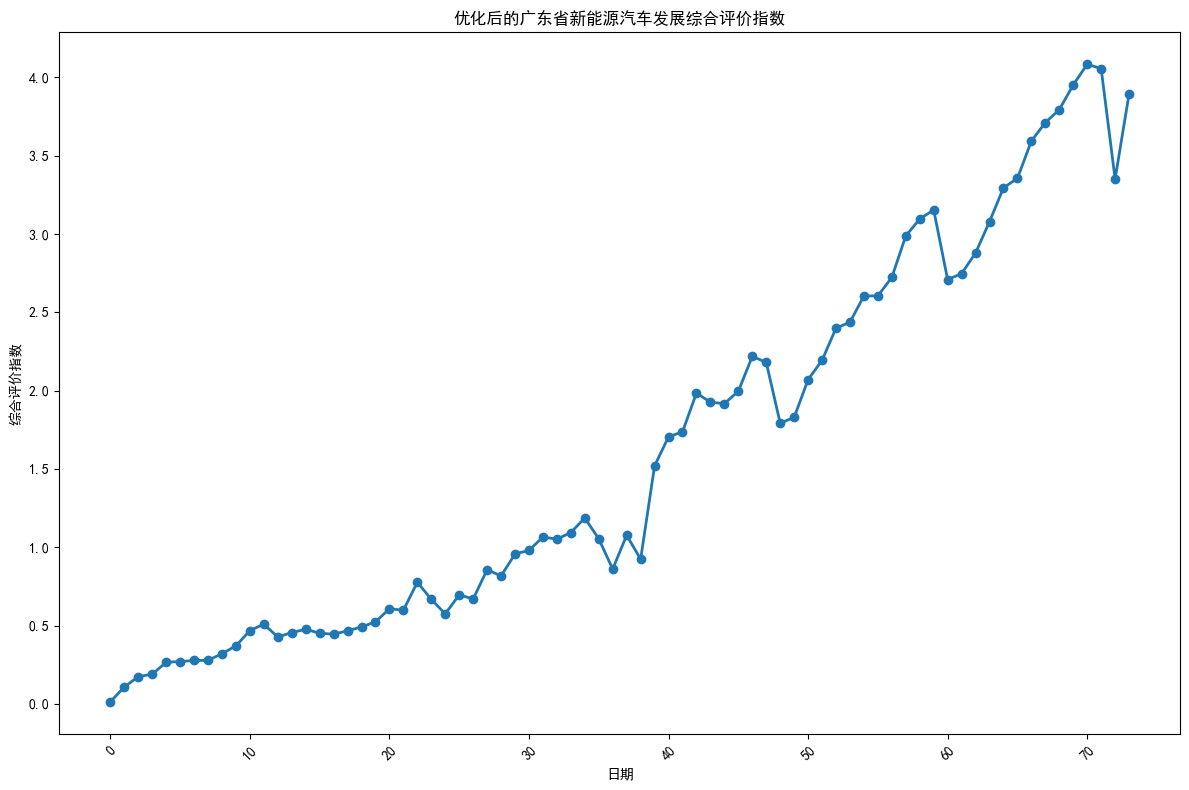

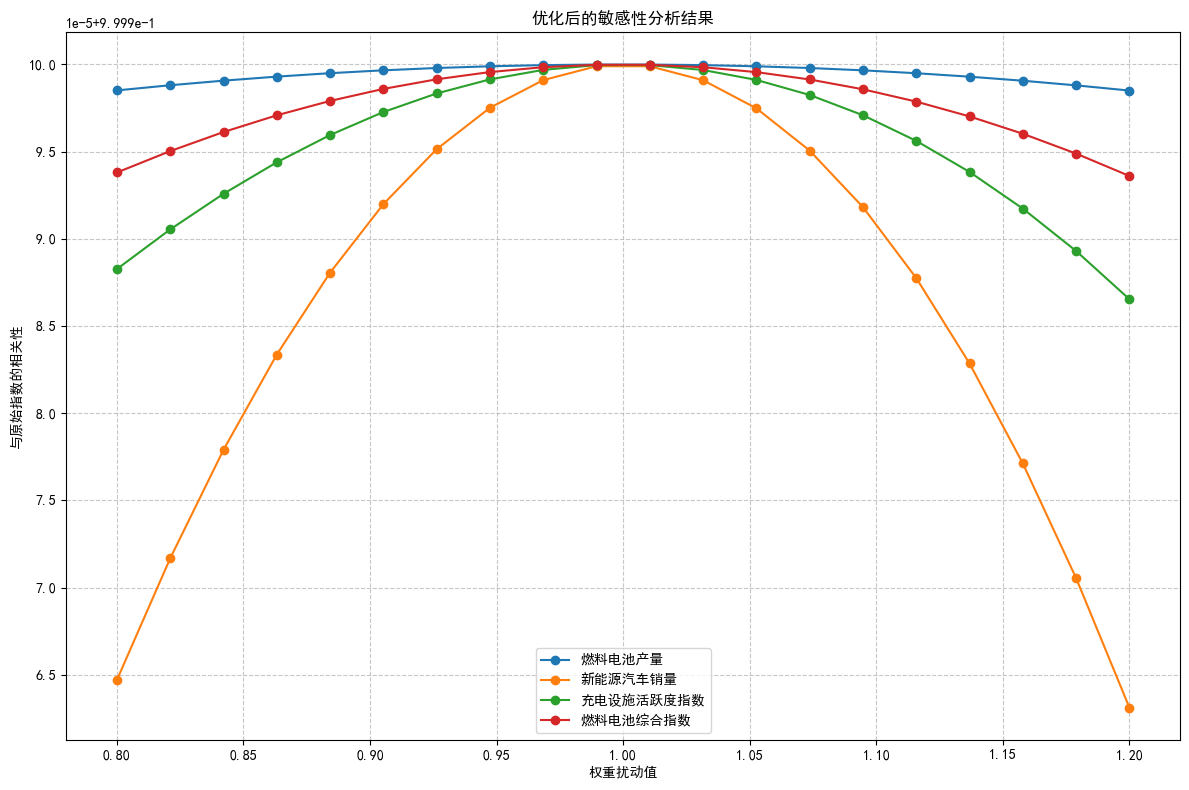

优化后的敏感性分析结果已保存到 optimized_sensitivity_analysis_results.xlsx


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取Excel文件
file_path = '热力图数据.xlsx'  # 替换为你的文件路径
df = pd.read_excel(file_path)

# 查看列名，确保列名正确
print("列名：", df.columns.tolist())

# 文件中的实际列名
actual_columns = [
    '燃料电池产量',
    '新能源汽车销量',
    '充电设施活跃度指数',
    '燃料电池综合指数'
]

# 代码中定义的列名
defined_columns = [
    '燃料电池产量',
    '新能源汽车销量',
    '充电设施活跃度指数',
    '燃料电池综合指数'
]

# 创建列名映射
column_mapping = dict(zip(actual_columns, defined_columns))

# 重命名列
df.rename(columns=column_mapping, inplace=True)

# 提取需要处理的列
columns = defined_columns

# 确保只对数值列进行操作
numeric_df = df[columns].apply(pd.to_numeric, errors='coerce')

# 数据标准化（Min-Max归一化）
scaler = MinMaxScaler()
df[columns] = scaler.fit_transform(numeric_df)

# 假设的AHP权重（根据专家判断或经验设定）
ahp_weights = {
    '燃料电池产量': 1,
    '新能源汽车销量': 3,
    '充电设施活跃度指数': 5,
    '燃料电池综合指数': 2
}

# 熵值法计算客观权重
def calculate_entropy_weights(data):
    # 避免除以零或负数
    data = np.where(data <= 0, 1e-10, data)
    # 计算熵值
    entropy = -data * np.log(data)
    entropy = np.nansum(entropy, axis=0)
    # 计算差异系数
    diff_coeff = 1 - entropy / np.log(len(data))
    # 计算客观权重
    weights = diff_coeff / np.sum(diff_coeff)
    return weights

# 提取归一化后的数据
normalized_data = df[columns].values

# 计算熵值法权重
entropy_weights = calculate_entropy_weights(normalized_data)

# 设置权重分配系数α
alpha_values = {
    '燃料电池产量': 0.15,
    '新能源汽车销量': 0.35,
    '充电设施活跃度指数': 0.25,
    '燃料电池综合指数': 0.25
}

# 计算综合权重
combined_weights = []
for i, column in enumerate(columns):
    ahp_weight = ahp_weights[column]
    ent_weight = entropy_weights[i]
    combined_weight = alpha_values[column] * ent_weight + (1 - alpha_values[column]) * ahp_weight
    combined_weights.append(combined_weight)

# 计算广东省新能源汽车发展的综合评价指数
comprehensive_index = np.sum(normalized_data * combined_weights, axis=1)

# 将指数添加到数据框
df['综合评价指数'] = comprehensive_index

# 使用随机森林回归模型进一步优化
X = df[columns]
y = df['综合评价指数']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练随机森林回归模型
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 预测
y_pred = rf.predict(X_test)

# 评估模型性能
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"随机森林回归模型的RMSE: {rmse}")

# 使用随机森林模型的特征重要性重新计算权重
feature_importances = rf.feature_importances_
rf_weights = feature_importances / np.sum(feature_importances)

# 结合随机森林权重和原有权重
final_weights = []
for i, column in enumerate(columns):
    final_weight = 0.5 * combined_weights[i] + 0.5 * rf_weights[i]
    final_weights.append(final_weight)

# 重新计算综合评价指数
final_comprehensive_index = np.sum(normalized_data * final_weights, axis=1)
df['优化后综合评价指数'] = final_comprehensive_index

# 保存结果到新的Excel文件
output_file_path = 'optimized_comprehensive_index.xlsx'
df.to_excel(output_file_path, index=False)

print(f"优化后的综合评价指数已计算并保存到 {output_file_path}")

# 可视化优化后的综合评价指数
plt.figure(figsize=(12, 8))
plt.plot(df.index, df['优化后综合评价指数'], marker='o', linestyle='-', linewidth=2)
plt.title('优化后的广东省新能源汽车发展综合评价指数')
plt.xlabel('日期')
plt.ylabel('综合评价指数')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 敏感性分析
def sensitivity_analysis(df, columns, alpha_values, ahp_weights, rf_weights, perturbation_range=0.1, steps=10):
    # 存储结果
    results = []
    
    # 对每个参数进行敏感性分析
    for param in columns:
        # 原始权重
        original_alpha = alpha_values[param]
        original_ahp_weight = ahp_weights[param]
        original_rf_weight = rf_weights[columns.index(param)]
        
        # 生成扰动值
        perturbations = np.linspace(1 - perturbation_range, 1 + perturbation_range, steps)
        
        for perturbation in perturbations:
            # 更新权重
            new_alpha = original_alpha * perturbation
            new_alpha = max(0, min(1, new_alpha))  # 确保权重在 [0, 1] 范围内
            
            new_combined_weight = new_alpha * entropy_weights[columns.index(param)] + (1 - new_alpha) * original_ahp_weight
            new_final_weight = 0.5 * new_combined_weight + 0.5 * original_rf_weight
            
            # 重新计算综合权重
            new_final_weights = final_weights.copy()
            new_final_weights[columns.index(param)] = new_final_weight
            
            # 计算新的综合评价指数
            new_comprehensive_index = np.sum(normalized_data * new_final_weights, axis=1)
            
            # 计算与原始指数的相关性
            original_index = df['优化后综合评价指数']
            correlation = np.corrcoef(original_index, new_comprehensive_index)[0, 1]
            
            # 记录结果
            results.append({
                '参数': param,
                '扰动值': perturbation,
                '相关性': correlation
            })
    
    return pd.DataFrame(results)

# 执行敏感性分析
sensitivity_results = sensitivity_analysis(df, columns, alpha_values, ahp_weights, rf_weights, perturbation_range=0.2, steps=20)

# 可视化敏感性分析结果
plt.figure(figsize=(12, 8))

for param in columns:
    param_results = sensitivity_results[sensitivity_results['参数'] == param]
    plt.plot(param_results['扰动值'], param_results['相关性'], marker='o', label=param)

plt.title('优化后的敏感性分析结果')
plt.xlabel('权重扰动值')
plt.ylabel('与原始指数的相关性')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 保存敏感性分析结果
sensitivity_results.to_excel('optimized_sensitivity_analysis_results.xlsx', index=False)
print("优化后的敏感性分析结果已保存到 optimized_sensitivity_analysis_results.xlsx")